In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")
# warnings.filterwarnings("ignore", message=".*does not have valid feature names.*")
# warnings.filterwarnings("ignore", message=".*LightGBM.*")

In [2]:
# Load data + constants
DATA_PATH = "career_dataset_final.csv"
LABEL_COL = "job_role"
DOMAIN_COL = "career_domain"
SEED = 42

df = pd.read_csv(DATA_PATH)

# Output folder for saved files
OUT_DIR = Path("artifacts_layer")
OUT_DIR.mkdir(exist_ok=True)
print("Dataset shape:", df.shape)
print("Total columns:", len(df.columns))

Dataset shape: (30000, 88)
Total columns: 88


In [3]:
if "career_domain" not in df.columns:
    raise ValueError("career_domain column not found in df. Can't build role_to_domain mapping.")

role_to_domain = (
    df[[LABEL_COL, DOMAIN_COL]]
    .dropna()
    .drop_duplicates()
    .groupby(LABEL_COL)[DOMAIN_COL]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
    .to_dict()
)

(OUT_DIR / "role_to_domain.json").write_text(json.dumps(role_to_domain, indent=2))
print("Saved role_to_domain.json")
print("Mapping size:", len(role_to_domain))

Saved role_to_domain.json
Mapping size: 40


In [4]:
# LAYER 1: Data Preparation & EDA

In [5]:
df.head()

,career_domain,math_scores,cs_fundamentals_scores,cgpa,cognitive_ability_score,programming_skill,web_dev_skill,mobile_dev_skill,data_analytics_skill,data_science_ml_skill,...,siem_experience_score,incident_response_cases,vuln_assessments_done,pentest_tools_known_count,compliance_frameworks_known_count,embedded_c_cpp_skill,microcontroller_projects_count,rtos_experience_score,firmware_debugging_skill,job_role
0,"Cloud, DevOps & Platform Engineering",71.42,80.80,8.16,5.81,5.82,5.77,4.27,5.59,2.96,...,2.14,0,0,0,0,2.54,0,2.59,2.44,Platform Engineer
1,Software Engineering,48.74,75.35,9.14,6.82,3.33,3.38,5.62,6.73,4.71,...,2.16,0,0,0,0,3.29,0,2.36,2.81,Application Support Engineer
2,Cybersecurity,75.15,75.85,8.48,3.73,5.90,4.69,1.68,2.89,4.38,...,5.24,2,3,0,5,0.61,0,1.91,5.83,GRC Analyst
3,Cybersecurity,58.15,73.91,8.72,6.28,6.53,2.29,1.57,6.86,2.48,...,7.83,13,12,6,0,1.92,0,3.40,3.08,Cybersecurity Engineer
4,Data & Artificial Intelligence,89.58,95.37,9.31,7.66,5.75,2.21,1.46,9.80,3.70,...,4.35,1,1,0,0,2.60,0,2.43,2.90,Data Analyst


In [6]:
df.dtypes

career_domain                         str
math_scores                       float64
cs_fundamentals_scores            float64
cgpa                              float64
cognitive_ability_score           float64
                                   ...   
embedded_c_cpp_skill              float64
microcontroller_projects_count      int64
rtos_experience_score             float64
firmware_debugging_skill          float64
job_role                              str
Length: 88, dtype: object

In [7]:
display(df.dtypes.value_counts().rename("count").to_frame())

,count
int64,50
float64,36
str,2


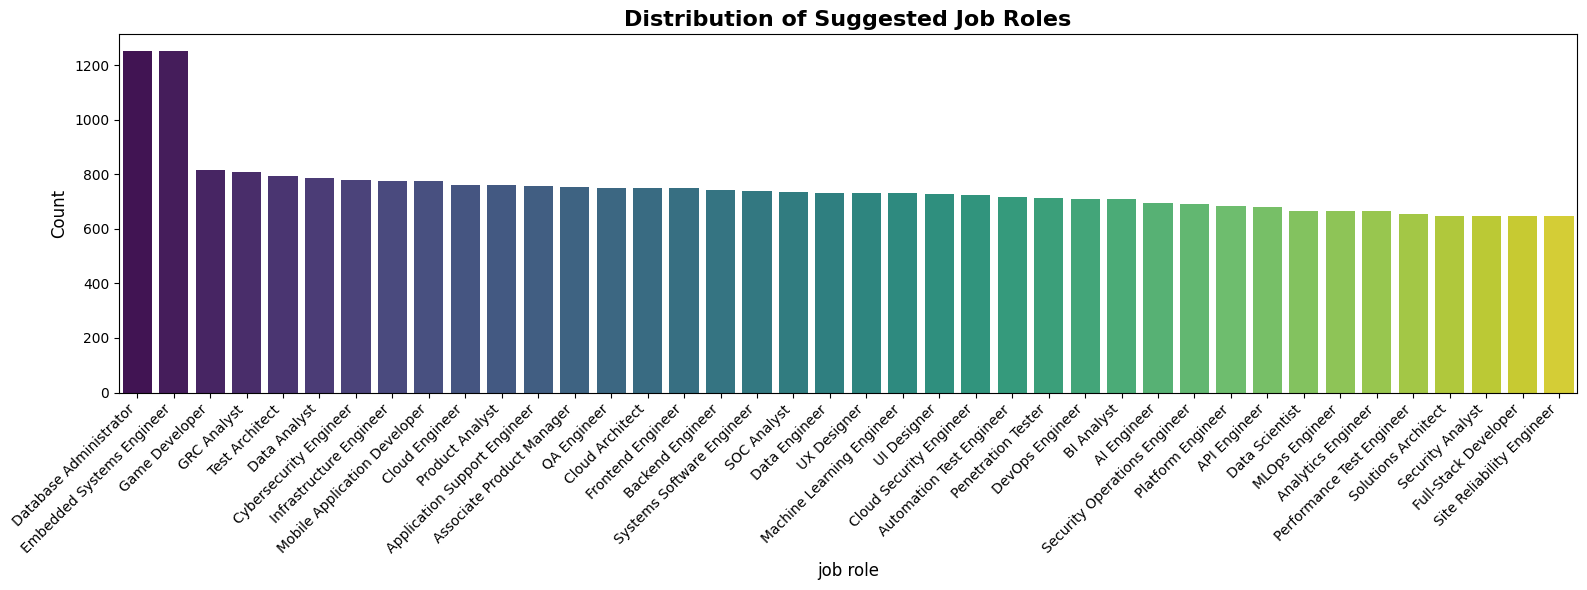

In [8]:
# Job Role Distribution (Full dataset)
plt.figure(figsize=(16, 6))
job_counts = df["job_role"].value_counts()
sns.barplot( x=job_counts.index,y=job_counts.values,hue=job_counts.index,palette="viridis",legend=False)
plt.title("Distribution of Suggested Job Roles", fontsize=16, fontweight="bold")
plt.xlabel("job role", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
df.isnull().sum()

,career_domain,math_scores,cs_fundamentals_scores,cgpa,cognitive_ability_score,programming_skill,web_dev_skill,mobile_dev_skill,data_analytics_skill,data_science_ml_skill,...,siem_experience_score,incident_response_cases,vuln_assessments_done,pentest_tools_known_count,compliance_frameworks_known_count,embedded_c_cpp_skill,microcontroller_projects_count,rtos_experience_score,firmware_debugging_skill,job_role
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
29996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
29997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
29998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
# Target columns check
required_cols = [LABEL_COL]
if DOMAIN_COL in df.columns:
    required_cols.append(DOMAIN_COL)

missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("Required columns present:", required_cols)

Required columns present: ['job_role', 'career_domain']


In [11]:
# Missing values check
missing_total = int(df.isna().sum().sum())
print("Total missing cells:", missing_total)

Total missing cells: 0


In [12]:
# Duplicate rows
dup_rate = float(df.duplicated().mean())
print("Duplicate row rate:", round(dup_rate, 6))

Duplicate row rate: 0.0


In [13]:
# Constant columns (only 1 unique value)
nunique = df.nunique(dropna=False)
constant_cols = nunique[nunique <= 1].index.tolist()
print("Constant columns count:", len(constant_cols))
if constant_cols:
    print("Sample constant columns:", constant_cols[:40])

Constant columns count: 0


In [14]:
# Leakage audit (simple checks)
def tokenize(text: str):
    return re.findall(r"[A-Za-z0-9_+\-]+", str(text).lower())

# Build label token set (words from job roles)
label_values = df[LABEL_COL].astype(str).unique().tolist()
label_tokens = set()
for lv in label_values:
    for t in tokenize(lv):
        if len(t) >= 4:
            label_tokens.add(t)

print("Label token count:", len(label_tokens))

# Suspicious column names (contains label tokens)
suspicious_cols = []
for c in df.columns:
    if c in [LABEL_COL, DOMAIN_COL]:
        continue
    name_tokens = set(tokenize(c))
    if len(name_tokens & label_tokens) > 0:
        suspicious_cols.append(c)

print("\nSuspicious columns by name (possible leakage):", suspicious_cols[:30])

# Text-like columns check (if any)
obj_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
text_like_cols = []
for c in obj_cols:
    if c in [LABEL_COL, DOMAIN_COL]:
        continue
    avg_len = df[c].fillna("").astype(str).map(len).mean()
    if avg_len >= 25:
        text_like_cols.append(c)

print("\nText-like columns:", text_like_cols)

# Save leakage report
leakage_report = {
    "label_tokens_count": int(len(label_tokens)),
    "suspicious_feature_names": suspicious_cols,
    "text_like_columns": text_like_cols,
}
(OUT_DIR / "leakage_report.json").write_text(json.dumps(leakage_report, indent=2))
print("\nSaved leakage_report.json")

Label token count: 41

Suspicious columns by name (possible leakage): []

Text-like columns: []

Saved leakage_report.json


In [15]:
# Target balance summary
role_counts = df[LABEL_COL].astype(str).value_counts()
imbalance_ratio = role_counts.max() / role_counts.min()

print("Number of roles:", role_counts.shape[0])
print("Min count:", int(role_counts.min()))
print("Max count:", int(role_counts.max()))
print("Imbalance ratio (max/min):", round(float(imbalance_ratio), 4))

display(
    pd.DataFrame({
        "count": role_counts.head(40),
        "percent": (role_counts.head(40) / len(df) * 100).round(2)
    })
)

Number of roles: 40
Min count: 646
Max count: 1250
Imbalance ratio (max/min): 1.935


,count,percent
job_role,,
Database Administrator,1250,4.17
Embedded Systems Engineer,1250,4.17
Game Developer,814,2.71
GRC Analyst,808,2.69
Test Architect,793,2.64
Data Analyst,785,2.62
Cybersecurity Engineer,777,2.59
Infrastructure Engineer,776,2.59
Mobile Application Developer,774,2.58


In [16]:
# Layer-2: Train / Val / Test Split (Stratified)

In [17]:
# Build X/y safely
y = df[LABEL_COL].astype(str)
drop_cols = [LABEL_COL]
if DOMAIN_COL in df.columns:
    drop_cols.append(DOMAIN_COL) 

X = df.drop(columns=drop_cols, errors="ignore").copy()
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Dropped:", drop_cols)

X shape: (30000, 86)
y shape: (30000,)
Dropped: ['job_role', 'career_domain']


In [18]:
# Train/Val/Test Split (stratified)
from sklearn.model_selection import train_test_split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

val_relative = 0.10 / (1.0 - 0.20) 
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=val_relative,
    random_state=SEED,
    stratify=y_trainval
)
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Classes:", y_train.nunique(), y_val.nunique(), y_test.nunique())

# Save split sizes
split_meta = {
    "seed": SEED,
    "sizes": {"train": len(X_train), "val": len(X_val), "test": len(X_test)},
    "dropped_cols": drop_cols
}
(OUT_DIR / "split_meta.json").write_text(json.dumps(split_meta, indent=2))
print("Saved split_meta.json")

# Save feature ranges from X_train only — used by backend to validate user inputs
feature_ranges = {}
for col in X_train.columns:
    feature_ranges[col] = {
        "min": float(X_train[col].min()),
        "max": float(X_train[col].max()),
        "dtype": str(X_train[col].dtype)
    }
(OUT_DIR / "feature_ranges.json").write_text(json.dumps(feature_ranges, indent=2))
print("Saved feature_ranges.json :", len(feature_ranges), "columns")


Train: (21000, 86) Val: (3000, 86) Test: (6000, 86)
Classes: 40 40 40
Saved split_meta.json
Saved feature_ranges.json : 86 columns


In [19]:
# Quick balance check — min and max samples per class in train
counts = pd.Series(y_train).value_counts()
print(f"Train class balance — min: {counts.min()}, max: {counts.max()}, ratio: {round(counts.max()/counts.min(), 2)}")

Train class balance — min: 452, max: 875, ratio: 1.94


In [20]:
# LAYER 3: Feature Engineering & Selection

In [21]:
# feature engineering
def add_advanced_engineered_features(X_in: pd.DataFrame) -> pd.DataFrame:
    X = X_in.copy()
    
    skill_interest_pairs = [
        ("programming_skill",       "interest_dev_overall",             "prog"),
        ("data_analytics_skill",    "interest_data_overall",            "data_analytics"),
        ("data_science_ml_skill",   "interest_data_overall",            "data_science"),
        ("cloud_devops_skill",      "interest_cloud_infra_overall",     "cloud"),
        ("cybersecurity_skill",     "interest_cybersecurity",           "cyber"),
        ("ui_ux_design_skill",      "interest_ui_ux_design",            "uiux"),
        ("business_analysis_skill", "interest_business_and_management", "biz"),
    ]
    for skill_col, interest_col, prefix in skill_interest_pairs:
        if skill_col in X.columns and interest_col in X.columns:
            X[f"{prefix}_alignment"] = X[skill_col] * X[interest_col]
            X[f"{prefix}_skill_gap"] = X[skill_col] - X[interest_col]


    # ── Domain composites ──────────────────────────────────────────────────────
    for cols, name in [
        (["programming_skill", "web_dev_skill", "mobile_dev_skill"],                "dev_composite"),
        (["data_analytics_skill", "data_science_ml_skill", "data_modeling_skill"],  "data_composite"),
        (["cloud_devops_skill", "cloud_aws", "cloud_azure"],                         "cloud_composite"),
        (["cybersecurity_skill", "siem_experience_score",
          "vuln_assessments_done", "pentest_tools_known_count"],                     "security_composite"),
        (["devops_docker", "devops_kubernetes", "devops_terraform"],                 "devops_composite"),
        (["embedded_c_cpp_skill", "microcontroller_projects_count",
          "rtos_experience_score", "firmware_debugging_skill"],                      "embedded_composite"),
    ]:
        present = [c for c in cols if c in X.columns]
        if present:
            X[name] = X[present].mean(axis=1)

    # ── Dominant domain — which domain is this student strongest in? ───────────
    composite_cols = [c for c in ["dev_composite", "data_composite", "cloud_composite",
                                   "security_composite", "devops_composite",
                                   "embedded_composite"] if c in X.columns]
    if composite_cols:
        X["dominant_domain_score"] = X[composite_cols].max(axis=1)
        X["dominant_domain_idx"]   = X[composite_cols].values.argmax(axis=1).astype(int)
        # 0=dev, 1=data, 2=cloud, 3=security, 4=devops, 5=embedded

    # ── Global skill stats ─────────────────────────────────────────────────────
    all_skill_cols = [c for c in X.columns if c.endswith("_skill")]
    if len(all_skill_cols) >= 3:
        X["skill_max"]         = X[all_skill_cols].max(axis=1)
        X["skill_min"]         = X[all_skill_cols].min(axis=1)
        X["skill_range"]       = X["skill_max"] - X["skill_min"]
        X["skill_mean"]        = X[all_skill_cols].mean(axis=1)
        X["skill_std"]         = X[all_skill_cols].std(axis=1)
        X["skills_above_mean"] = X[all_skill_cols].gt(X["skill_mean"], axis=0).sum(axis=1)
        # Specialist vs generalist — high value = one strong skill, low = balanced
        X["skill_focus_ratio"] = X["skill_max"] / (X["skill_mean"] + 1e-6)

    # ── Activity & experience ──────────────────────────────────────────────────
    act_cols = [c for c in ["project_count", "github_commits_90d",
                             "internship_experience_count"] if c in X.columns]
    if act_cols:
        X["activity_total"] = X[act_cols].sum(axis=1)
        X["activity_max"]   = X[act_cols].max(axis=1)
        X["is_active"]      = (X["activity_total"] > 0).astype(int)

    if "internship_experience_count" in X.columns:
        X["has_internship"] = (X["internship_experience_count"] > 0).astype(int)

    # ── Certifications ─────────────────────────────────────────────────────────
    if "certifications_total" in X.columns:
        X["cert_level_bin"] = pd.cut(
            X["certifications_total"],
            bins=[-1, 0, 1, 3, float("inf")],
            labels=[0, 1, 2, 3]
        ).astype(int)
        X["is_certified"] = (X["certifications_total"] > 0).astype(int)

    # ── Academic ───────────────────────────────────────────────────────────────
    academic_cols = [c for c in ["math_scores", "cs_fundamentals_scores",
                                  "cognitive_ability_score"] if c in X.columns]
    if academic_cols:
        X["academic_composite"] = X[academic_cols].mean(axis=1)

    if "cgpa" in X.columns:
        X["cgpa_normalized"]  = X["cgpa"] / 10.0
        X["is_top_performer"] = (X["cgpa"] >= 8.5).astype(int)

    # ── Project totals by type ─────────────────────────────────────────────────
    for cols, name in [
        (["projects_backend", "projects_frontend", "projects_fullstack"],             "project_dev_total"),
        (["projects_data_analytics", "projects_data_engineering", "projects_ml_ai"], "project_data_total"),
        (["projects_security_defense", "projects_security_offense"],                  "project_security_total"),
        (["projects_cloud", "projects_devops"],                                       "project_cloud_ops"),
        (["projects_mobile_android", "projects_mobile_ios",
          "projects_mobile_flutter"],                                                  "project_mobile_total"),
    ]:
        present = [c for c in cols if c in X.columns]
        if present:
            X[name] = X[present].sum(axis=1)

    # ── Tech stack totals ──────────────────────────────────────────────────────
    for cols, name in [
        (["frontend_react", "frontend_angular"],                       "frontend_stack"),
        (["backend_node", "backend_django", "backend_spring"],         "backend_stack"),
        (["data_tool_spark", "data_tool_airflow", "data_tool_kafka"],  "data_stack"),
        (["security_tool_siem", "security_tool_wireshark",
          "security_tool_burpsuite"],                                   "security_stack"),
        (["mobile_kotlin", "mobile_flutter"],                          "mobile_stack"),
        (["observability_prometheus", "observability_grafana"],        "observability_stack"),
    ]:
        present = [c for c in cols if c in X.columns]
        if present:
            X[name] = X[present].sum(axis=1)

    # ── Security depth ─────────────────────────────────────────────────────────
    all_sec = [c for c in ["cybersecurity_skill", "siem_experience_score",
                            "vuln_assessments_done", "pentest_tools_known_count",
                            "incident_response_cases",
                            "compliance_frameworks_known_count"] if c in X.columns]
    if all_sec:
        X["security_total"]      = X[all_sec].sum(axis=1)
        X["is_security_focused"] = (X["security_total"] >= 5).astype(int)

    pentest_cols = [c for c in ["pentest_tools_known_count", "security_tool_burpsuite",
                                 "projects_security_offense"] if c in X.columns]
    if pentest_cols:
        X["pentest_focused"] = X[pentest_cols].sum(axis=1)

    defense_cols = [c for c in ["siem_experience_score", "incident_response_cases",
                                 "security_tool_siem",
                                 "projects_security_defense"] if c in X.columns]
    if defense_cols:
        X["defensive_focused"] = X[defense_cols].sum(axis=1)

    # ── Soft skills ────────────────────────────────────────────────────────────
    soft_cols = [c for c in ["teamwork_behavior", "communication_skill",
                              "learning_motivation",
                              "professional_discipline_score"] if c in X.columns]
    if soft_cols:
        X["soft_skills_total"] = X[soft_cols].sum(axis=1)
        X["soft_skills_mean"]  = X[soft_cols].mean(axis=1)
        X["is_strong_soft"]    = (X["soft_skills_mean"] >= 7).astype(int)

    return X

In [22]:
# Apply feature engineering — wrapped in try/except so a bad input never crashes
_fe_failed = False
try:
    X_train_fe = add_advanced_engineered_features(X_train)
    X_val_fe   = add_advanced_engineered_features(X_val)
    X_test_fe  = add_advanced_engineered_features(X_test)
except Exception as e:
    warnings.warn(f"Feature engineering failed: {e}. Falling back to original features.")
    X_train_fe = X_train.copy()
    X_val_fe   = X_val.copy()
    X_test_fe  = X_test.copy()
    _fe_failed = True

# ── Column consistency check — all 3 sets must have identical columns ──────────
assert list(X_train_fe.columns) == list(X_val_fe.columns) == list(X_test_fe.columns), \
    " Column mismatch between train/val/test after feature engineering!"

# ── Summary report ─────────────────────────────────────────────────────────────
original_cols   = set(X_train.columns)
engineered_cols = set(X_train_fe.columns) - original_cols

print("=" * 60)
print("  Feature Engineering Summary")
print("=" * 60)
if _fe_failed:
    print(" Engineering FAILED — using original features only")
else:
    print(f"  Original features   : {len(original_cols)}")
    print(f"  Engineered features : {len(engineered_cols)}")
    print(f"  Total features      : {X_train_fe.shape[1]}")
    print(f"\n  New features created:")
    for i, col in enumerate(sorted(engineered_cols), 1):
        print(f"    {i:>2}. {col}")
print("=" * 60)

  Feature Engineering Summary
  Original features   : 86
  Engineered features : 56
  Total features      : 142

  New features created:
     1. academic_composite
     2. activity_max
     3. activity_total
     4. backend_stack
     5. biz_alignment
     6. biz_skill_gap
     7. cert_level_bin
     8. cgpa_normalized
     9. cloud_alignment
    10. cloud_composite
    11. cloud_skill_gap
    12. cyber_alignment
    13. cyber_skill_gap
    14. data_analytics_alignment
    15. data_analytics_skill_gap
    16. data_composite
    17. data_science_alignment
    18. data_science_skill_gap
    19. data_stack
    20. defensive_focused
    21. dev_composite
    22. devops_composite
    23. dominant_domain_idx
    24. dominant_domain_score
    25. embedded_composite
    26. frontend_stack
    27. has_internship
    28. is_active
    29. is_certified
    30. is_security_focused
    31. is_strong_soft
    32. is_top_performer
    33. mobile_stack
    34. observability_stack
    35. pentest_focus

In [23]:
# Correlation-based feature selection (train only)
# UPGRADED: keeps the higher-variance feature from each correlated pair
# instead of blindly dropping the first alphabetically
def find_high_corr_drops(X_train_df: pd.DataFrame, threshold: float = 0.85) -> list:
    numeric_cols = [c for c in X_train_df.columns
                    if pd.api.types.is_numeric_dtype(X_train_df[c])]
    X_num = X_train_df[numeric_cols].copy()

    if X_num.shape[1] < 2:
        return []

    corr  = X_num.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    to_drop = set()
    for col in upper.columns:
        partners = upper.index[upper[col] > threshold].tolist()
        for partner in partners:
            # Drop the one with LOWER std (less informative)
            # Keep the one with HIGHER std (more spread = more signal)
            if X_num[col].std() < X_num[partner].std():
                to_drop.add(col)
            else:
                to_drop.add(partner)

    return list(to_drop)


corr_threshold = 0.85
drop_corr_cols = find_high_corr_drops(X_train_fe, threshold=corr_threshold)

print("Correlated drop count:", len(drop_corr_cols))
print("Sample drop cols:", drop_corr_cols[:20])

# Apply same drop list to val/test
X_train_sel = X_train_fe.drop(columns=drop_corr_cols, errors="ignore")
X_val_sel   = X_val_fe.drop(columns=drop_corr_cols, errors="ignore")
X_test_sel  = X_test_fe.drop(columns=drop_corr_cols, errors="ignore")

print("After selection shapes:", X_train_sel.shape, X_val_sel.shape, X_test_sel.shape)

# Save selection artifacts
(OUT_DIR / "dropped_correlated_features.json").write_text(
    json.dumps({"threshold": corr_threshold, "dropped_features": drop_corr_cols}, indent=2)
)
(OUT_DIR / "selected_features.json").write_text(
    json.dumps({"selected_features": X_train_sel.columns.tolist()}, indent=2)
)

print("Saved dropped_correlated_features.json and selected_features.json")

Correlated drop count: 16
Sample drop cols: ['security_total', 'cgpa_normalized', 'cloud_composite', 'ui_ux_design_skill', 'pentest_tools_known_count', 'defensive_focused', 'soft_skills_mean', 'security_composite', 'incident_response_cases', 'projects_security_defense', 'activity_max', 'data_science_ml_skill', 'github_commits_90d', 'cert_level_bin', 'projects_mobile_android', 'cybersecurity_skill']
After selection shapes: (21000, 126) (3000, 126) (6000, 126)
Saved dropped_correlated_features.json and selected_features.json


Numeric columns: 142

Top 20 correlated feature pairs [TRAIN]:


,,abs_corr
soft_skills_mean,soft_skills_total,1.000000
project_mobile_total,projects_mobile_android,1.000000
cgpa_normalized,cgpa,1.000000
activity_max,github_commits_90d,0.999992
activity_total,github_commits_90d,0.999557
activity_max,activity_total,0.999554
cloud_composite,cloud_devops_skill,0.968368
defensive_focused,incident_response_cases,0.960084
pentest_focused,pentest_tools_known_count,0.956777
security_total,security_composite,0.956409


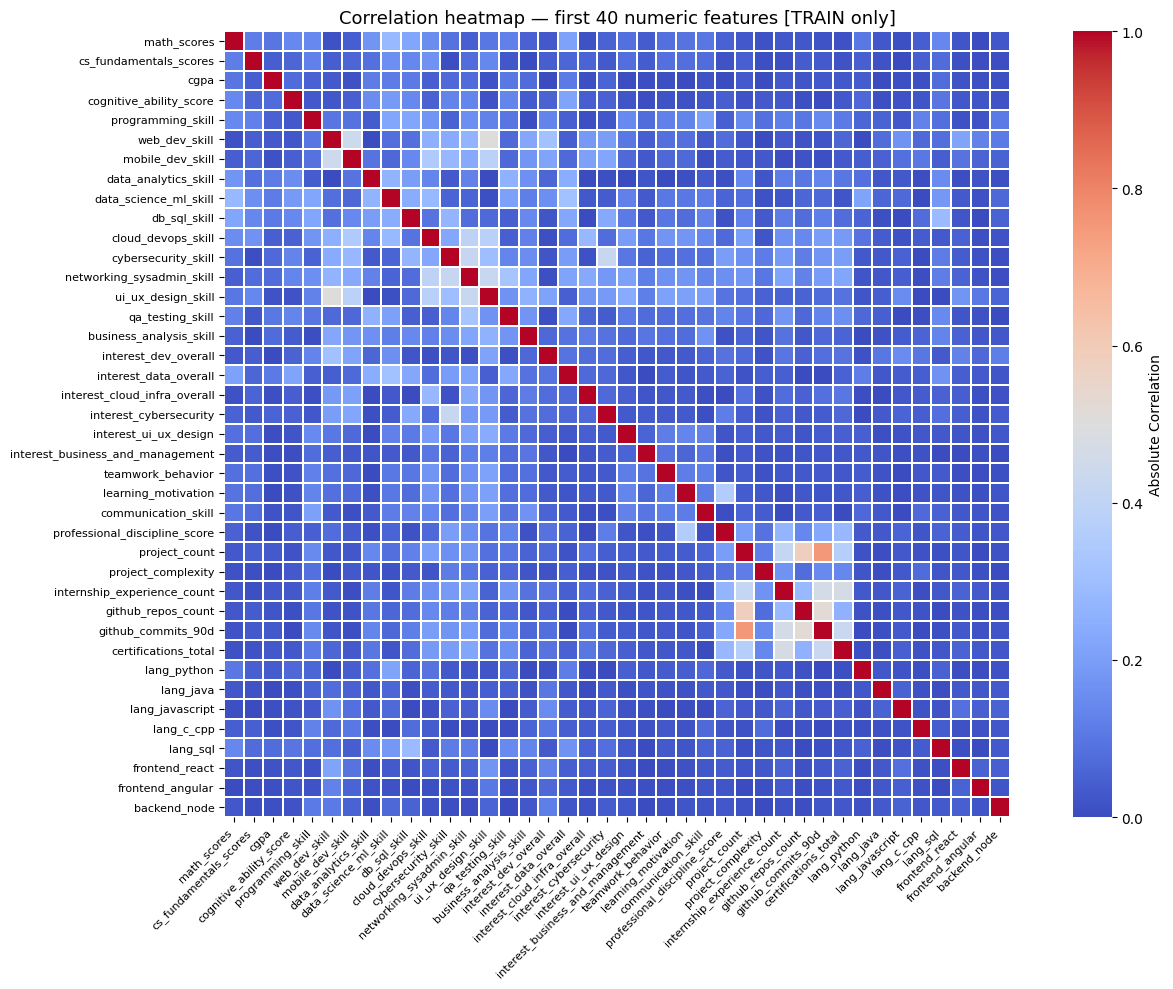


Pairs with correlation > 0.85 : 20
These will be dropped in the next step.


In [24]:
# Correlation report (train only)
num_cols = [c for c in X_train_fe.columns
            if pd.api.types.is_numeric_dtype(X_train_fe[c])]
print("Numeric columns:", len(num_cols))

if len(num_cols) >= 2:
    # ── Build upper-triangle correlation matrix ───────────────────────────────
    corr_full = X_train_fe[num_cols].corr().abs()
    upper     = corr_full.where(
        np.triu(np.ones(corr_full.shape), k=1).astype(bool)
    )

    # ── Top 20 unique correlated pairs (no duplicates) ────────────────────────
    pairs = (
        upper.unstack()
        .dropna()
        .sort_values(ascending=False)
    )
    pairs = pairs[pairs > 0].head(20)
    print("\nTop 20 correlated feature pairs [TRAIN]:")
    display(pairs.to_frame("abs_corr"))

    # ── Heatmap (seaborn — correct tool for correlation) ─────────────────────
    N          = min(40, len(num_cols))
    small_cols = num_cols[:N]
    corr_small = X_train_fe[small_cols].corr().abs()  # absolute, consistent

    plt.figure(figsize=(14, 10))
    sns.heatmap( corr_small, vmin=0, vmax=1, cmap="coolwarm", square=True, linewidths=0.3, annot=False, cbar_kws={"label": "Absolute Correlation"},)
    plt.title(f"Correlation heatmap — first {N} numeric features [TRAIN only]", fontsize=13)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(rotation=0,  fontsize=8)
    plt.tight_layout()
    plt.show()

    # ── Quick summary stat ────────────────────────────────────────────────────
    high_corr_count = (upper > 0.85).sum().sum()
    print(f"\nPairs with correlation > 0.85 : {high_corr_count}")
    print(f"These will be dropped in the next step.")

else:
    print("Not enough numeric columns for correlation analysis.")

In [25]:
# Layer 4: Preprocessing (Fit on TRAIN only) + Safety Checks

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import joblib

# Detect numeric vs categorical columns
numeric_cols = [c for c in X_train_sel.columns if pd.api.types.is_numeric_dtype(X_train_sel[c])]
categorical_cols = [c for c in X_train_sel.columns if c not in numeric_cols]

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))
print("Example numeric:", numeric_cols[:10])
print("Example categorical:", categorical_cols[:10])


Numeric columns: 126
Categorical columns: 0
Example numeric: ['math_scores', 'cs_fundamentals_scores', 'cgpa', 'cognitive_ability_score', 'programming_skill', 'web_dev_skill', 'mobile_dev_skill', 'data_analytics_skill', 'db_sql_skill', 'cloud_devops_skill']
Example categorical: []


In [27]:
# Numeric preprocessing
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categorical preprocessing
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# Combine them
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ],
    remainder="drop"
)
print("Preprocessor ready.")
preprocess

Preprocessor ready.


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [28]:
# Fit on TRAIN only + transform VAL/TEST
X_train_proc = preprocess.fit_transform(X_train_sel)
X_val_proc = preprocess.transform(X_val_sel)
X_test_proc = preprocess.transform(X_test_sel)

print("Processed shapes:")
print("Train:", X_train_proc.shape)
print("Val  :", X_val_proc.shape)
print("Test :", X_test_proc.shape)

Processed shapes:
Train: (21000, 126)
Val  : (3000, 126)
Test : (6000, 126)


In [29]:
# Safety checks (shapes, NaN/Inf)
# Safety check 1 — column order must be identical across all splits
def check_same_columns():
    a = list(X_train_sel.columns)
    b = list(X_val_sel.columns)
    c = list(X_test_sel.columns)
    train_val  = a == b
    train_test = a == c
    print("Train vs Val  columns identical:", train_val)
    print("Train vs Test columns identical:", train_test)
    if not train_val or not train_test:
        raise ValueError("Column mismatch detected — DO NOT proceed to training!")

check_same_columns()

# Safety check 2 — no NaN or Inf in processed arrays
def check_matrix_ok(mat, name):
    arr = mat.toarray() if hasattr(mat, "toarray") else np.asarray(mat)
    n_nan = int(np.isnan(arr).sum())
    n_inf = int(np.isinf(arr).sum())
    status = "✅" if n_nan == 0 and n_inf == 0 else "❌"
    print(f"  {status}  {name} — NaNs: {n_nan} | Infs: {n_inf}")

print("\nMatrix quality checks:")
check_matrix_ok(X_train_proc, "X_train_proc")
check_matrix_ok(X_val_proc,   "X_val_proc  ")
check_matrix_ok(X_test_proc,  "X_test_proc ")

Train vs Val  columns identical: True
Train vs Test columns identical: True

Matrix quality checks:
  ✅  X_train_proc — NaNs: 0 | Infs: 0
  ✅  X_val_proc   — NaNs: 0 | Infs: 0
  ✅  X_test_proc  — NaNs: 0 | Infs: 0


In [30]:
# ── ROLE MERGE MAP ────────────────────────────────────────────────────────────
# 40 original roles → 30 final classes (based on cosine-similarity analysis)

ROLE_MERGE_MAP = {
    # Cloud / DevOps / Platform (7 → 5)
    "Cloud Engineer"            : "Cloud Engineer & Platform/SRE",
    "Platform Engineer"         : "Cloud Engineer & Platform/SRE",
    "Site Reliability Engineer" : "Cloud Engineer & Platform/SRE",

    # Data & AI (8 → 4)
    "AI Engineer"               : "Data Scientist / ML / AI Engineer",
    "Data Scientist"            : "Data Scientist / ML / AI Engineer",
    "Machine Learning Engineer" : "Data Scientist / ML / AI Engineer",
    "BI Analyst"                : "Data Scientist / ML / AI Engineer",
    "Analytics Engineer"        : "Data & Analytics Engineer",
    "Data Engineer"             : "Data & Analytics Engineer",

    # Cybersecurity (7 → 4)
    "SOC Analyst"                  : "Security Operations Analyst",
    "Security Analyst"             : "Security Operations Analyst",
    "Security Operations Engineer" : "Security Operations Analyst",
    "Cybersecurity Engineer"       : "Cybersecurity & Cloud Security Engineer",
    "Cloud Security Engineer"      : "Cybersecurity & Cloud Security Engineer",

    # QA & Testing (4 → 3)
    "QA Engineer"              : "QA & Automation Test Engineer",
    "Automation Test Engineer" : "QA & Automation Test Engineer",
}

# ── Save role_merge_map.json ──────────────────────────────────────────────────
(OUT_DIR / "role_merge_map.json").write_text(json.dumps(ROLE_MERGE_MAP, indent=2))
print(f"Saved role_merge_map.json — {len(ROLE_MERGE_MAP)} mappings")

# ── Apply merge to y splits (X is never touched) ─────────────────────────────
y_train_mapped = y_train.replace(ROLE_MERGE_MAP)
y_val_mapped   = y_val.replace(ROLE_MERGE_MAP)
y_test_mapped  = y_test.replace(ROLE_MERGE_MAP)

# ── Label encoder — fit on TRAIN only, single instance ───────────────────────
label_encoder = LabelEncoder()
y_train_enc   = label_encoder.fit_transform(y_train_mapped.astype(str))
y_val_enc     = label_encoder.transform(y_val_mapped.astype(str))
y_test_enc    = label_encoder.transform(y_test_mapped.astype(str))

print(f"\nOriginal roles : {y_train.nunique()}")
print(f"Merged roles   : {y_train_mapped.nunique()}")
print(f"Classes        : {len(label_encoder.classes_)}")
print("\nFinal 30 role list:")
for i, r in enumerate(label_encoder.classes_):
    print(f"  {i:>2}.  {r}")

assert len(label_encoder.classes_) == 30, \
    f"Expected 30 classes, got {len(label_encoder.classes_)} — check ROLE_MERGE_MAP"
print("\n✅ Exactly 30 classes confirmed")

# ── Save label encoder ────────────────────────────────────────────────────────
joblib.dump(label_encoder, OUT_DIR / "label_encoder.joblib")
print("Saved label_encoder.joblib (30 classes)")

# ── FIX: Rebuild role_to_domain using MERGED role names ──────────────────────
# Load the original 40-role mapping saved in Layer 1
with open(OUT_DIR / "role_to_domain.json") as f:
    original_role_to_domain = json.load(f)

# Remap old role names → merged role names
role_to_domain_merged = {}
for old_role, domain in original_role_to_domain.items():
    new_role = ROLE_MERGE_MAP.get(old_role, old_role)
    role_to_domain_merged[new_role] = domain

(OUT_DIR / "role_to_domain.json").write_text(
    json.dumps(role_to_domain_merged, indent=2)
)
print(f"Saved role_to_domain.json ({len(role_to_domain_merged)} roles) ✅")

Saved role_merge_map.json — 16 mappings

Original roles : 40
Merged roles   : 30
Classes        : 30

Final 30 role list:
   0.  API Engineer
   1.  Application Support Engineer
   2.  Associate Product Manager
   3.  Backend Engineer
   4.  Cloud Architect
   5.  Cloud Engineer & Platform/SRE
   6.  Cybersecurity & Cloud Security Engineer
   7.  Data & Analytics Engineer
   8.  Data Analyst
   9.  Data Scientist / ML / AI Engineer
  10.  Database Administrator
  11.  DevOps Engineer
  12.  Embedded Systems Engineer
  13.  Frontend Engineer
  14.  Full-Stack Developer
  15.  GRC Analyst
  16.  Game Developer
  17.  Infrastructure Engineer
  18.  MLOps Engineer
  19.  Mobile Application Developer
  20.  Penetration Tester
  21.  Performance Test Engineer
  22.  Product Analyst
  23.  QA & Automation Test Engineer
  24.  Security Operations Analyst
  25.  Solutions Architect
  26.  Systems Software Engineer
  27.  Test Architect
  28.  UI Designer
  29.  UX Designer

✅ Exactly 30 classes

In [31]:
# Save preprocessor — fitted on train only
joblib.dump(preprocess, OUT_DIR / "preprocess.joblib")
print("Saved preprocess.joblib")

# Save final feature list
final_feature_list = X_train_sel.columns.tolist()
(OUT_DIR / "final_feature_list.json").write_text(
    json.dumps({"final_feature_list": final_feature_list}, indent=2)
)
print("Saved final_feature_list.json")

# Save exact feature order — backend uses this to reindex input
(OUT_DIR / "feature_order.json").write_text(
    json.dumps(final_feature_list, indent=2)
)
print(f"Saved feature_order.json — {len(final_feature_list)} features")

# Save preprocessing output feature names (for debugging)
try:
    feature_names_out = preprocess.get_feature_names_out().tolist()
except Exception:
    feature_names_out = None

(OUT_DIR / "preprocess_feature_names.json").write_text(
    json.dumps({"feature_names_out": feature_names_out}, indent=2)
)
print("Saved preprocess_feature_names.json")

print("\n✅ All Layer 4 artifacts saved successfully!")
print(f"   preprocess.joblib         → fitted scaler")
print(f"   label_encoder.joblib      → 30 classes")
print(f"   role_to_domain.json       → {len(role_to_domain_merged)} role→domain mappings")
print(f"   feature_order.json        → {len(final_feature_list)} columns in exact order")

Saved preprocess.joblib
Saved final_feature_list.json
Saved feature_order.json — 126 features
Saved preprocess_feature_names.json

✅ All Layer 4 artifacts saved successfully!
   preprocess.joblib         → fitted scaler
   label_encoder.joblib      → 30 classes
   role_to_domain.json       → 30 role→domain mappings
   feature_order.json        → 126 columns in exact order


In [32]:
# LAYER 5: Model Selection & Training

In [33]:
import time
import json
import joblib
import numpy as np
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, log_loss, top_k_accuracy_score,
    classification_report, confusion_matrix,
)
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from xgboost                 import XGBClassifier
import lightgbm              as lgb
from catboost                import CatBoostClassifier

print("✅ All imports successful.")
print("   LightGBM | XGBoost | CatBoost | ExtraTrees | HistGBM | LogisticRegression")

✅ All imports successful.
   LightGBM | XGBoost | CatBoost | ExtraTrees | HistGBM | LogisticRegression


In [34]:
# ── Training & evaluation helpers ─────────────────────────────────────────────
def eval_on_val_metrics(model, X_tr, y_tr, X_v, y_v, k=3):
    model.fit(X_tr, y_tr)
    pred  = model.predict(X_v)
    n_cls = len(label_encoder.classes_)
    metrics = {
        "accuracy":        float(accuracy_score(y_v, pred)),
        "macro_f1":        float(f1_score(y_v, pred, average="macro")),
        "macro_precision": float(precision_score(y_v, pred,
                                 average="macro", zero_division=0)),
        "macro_recall":    float(recall_score(y_v, pred,
                                 average="macro", zero_division=0)),
        "top3_acc":        None,
        "top3_f1":         None,
        "log_loss":        None,
    }
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_v)
        metrics["log_loss"] = float(log_loss(y_v, proba,
                                    labels=np.arange(n_cls)))
        metrics["top3_acc"] = float(top_k_accuracy_score(y_v, proba,
                                    k=k, labels=np.arange(n_cls)))
        topk_idx = np.argsort(proba, axis=1)[:, -k:]
        hit = np.array([y_v[i] in topk_idx[i]
                        for i in range(len(y_v))], dtype=int)
        metrics["top3_f1"] = float(f1_score(np.ones_like(hit),
                                   hit, average="binary"))
    return metrics, model


def print_metrics_list(title: str, metrics: dict, elapsed: float = None):
    order = ["accuracy", "macro_f1", "macro_precision",
             "macro_recall", "top3_acc", "top3_f1", "log_loss"]
    print(f"\n{title}")
    for key in order:
        val = metrics.get(key, None)
        if val is None:
            print(f"  {key}: None")
        else:
            print(f"  {key}: {val:.6f}")
    if elapsed is not None:
        print(f"  training_time: {elapsed:.1f}s  ({elapsed/60:.2f} min)")


def top3_f1_from_proba(y_true: np.ndarray, proba: np.ndarray, k: int = 3) -> float:
    topk_idx = np.argsort(proba, axis=1)[:, -k:]
    hit = np.array([y_true[i] in topk_idx[i]
                    for i in range(len(y_true))], dtype=int)
    return float(f1_score(np.ones_like(hit), hit, average="binary"))


print("✅ Helpers ready.")

✅ Helpers ready.


In [35]:
# ── MODEL 1: LightGBM ─────────────────────────────────────────────────────────
t0 = time.time()

lgbm_model = lgb.LGBMClassifier(
    n_estimators      = 800,
    learning_rate     = 0.07,
    num_leaves        = 80,
    max_depth         = -1,
    min_child_samples = 25,
    subsample         = 0.85,
    colsample_bytree  = 0.85,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    class_weight      = "balanced",
    random_state      = SEED,
    verbosity         = -1,
    n_jobs            = -1,
)

lgbm_model.fit(
    X_train_proc, y_train_enc,
    eval_set  = [(X_val_proc, y_val_enc)],
    callbacks = [
        lgb.early_stopping(40, verbose=False),
        lgb.log_evaluation(period=-1),
    ],
)

lgbm_pred    = lgbm_model.predict(X_val_proc)
lgbm_proba   = lgbm_model.predict_proba(X_val_proc)
n_cls        = len(label_encoder.classes_)
lgbm_elapsed = time.time() - t0

lgbm_metrics = {
    "accuracy":        float(accuracy_score(y_val_enc, lgbm_pred)),
    "macro_f1":        float(f1_score(y_val_enc, lgbm_pred, average="macro")),
    "macro_precision": float(precision_score(y_val_enc, lgbm_pred,
                             average="macro", zero_division=0)),
    "macro_recall":    float(recall_score(y_val_enc, lgbm_pred,
                             average="macro", zero_division=0)),
    "top3_acc":        float(top_k_accuracy_score(y_val_enc, lgbm_proba,
                             k=3, labels=np.arange(n_cls))),
    "top3_f1":         float(top3_f1_from_proba(y_val_enc, lgbm_proba, k=3)),
    "log_loss":        float(log_loss(y_val_enc, lgbm_proba,
                             labels=np.arange(n_cls))),
}
lgbm_fitted = lgbm_model
print_metrics_list("LightGBM VAL", lgbm_metrics, lgbm_elapsed)
print(f"  Best iteration: {lgbm_model.best_iteration_}")


LightGBM VAL
  accuracy: 0.830000
  macro_f1: 0.816358
  macro_precision: 0.817535
  macro_recall: 0.816766
  top3_acc: 0.986333
  top3_f1: 0.993120
  log_loss: 0.482498
  training_time: 12.6s  (0.21 min)
  Best iteration: 113


In [36]:
# ── MODEL 2: XGBoost ──────────────────────────────────────────────────────────
t0 = time.time()

xgb_model = XGBClassifier(
    n_estimators          = 800,
    learning_rate         = 0.07,
    max_depth             = 5,
    min_child_weight      = 4,
    subsample             = 0.75,
    colsample_bytree      = 0.75,
    colsample_bylevel     = 0.6,
    gamma                 = 0.2,
    reg_alpha             = 0.2,
    reg_lambda            = 3.0,
    eval_metric           = "mlogloss",
    early_stopping_rounds = 40,
    random_state          = SEED,
    n_jobs                = -1,
)

xgb_sample_weights = compute_sample_weight(
    class_weight = "balanced",
    y            = y_train_enc,
)

xgb_model.fit(
    X_train_proc, y_train_enc,
    sample_weight = xgb_sample_weights,
    eval_set      = [(X_val_proc, y_val_enc)],
    verbose       = False,
)

xgb_pred    = xgb_model.predict(X_val_proc)
xgb_proba   = xgb_model.predict_proba(X_val_proc)
xgb_elapsed = time.time() - t0

xgb_metrics = {
    "accuracy":        float(accuracy_score(y_val_enc, xgb_pred)),
    "macro_f1":        float(f1_score(y_val_enc, xgb_pred, average="macro")),
    "macro_precision": float(precision_score(y_val_enc, xgb_pred,
                             average="macro", zero_division=0)),
    "macro_recall":    float(recall_score(y_val_enc, xgb_pred,
                             average="macro", zero_division=0)),
    "top3_acc":        float(top_k_accuracy_score(y_val_enc, xgb_proba,
                             k=3, labels=np.arange(n_cls))),
    "top3_f1":         float(top3_f1_from_proba(y_val_enc, xgb_proba, k=3)),
    "log_loss":        float(log_loss(y_val_enc, xgb_proba,
                             labels=np.arange(n_cls))),
}
xgb_fitted = xgb_model
print_metrics_list("XGBoost VAL", xgb_metrics, xgb_elapsed)
print(f"  Best iteration: {xgb_model.best_iteration}")


XGBoost VAL
  accuracy: 0.839333
  macro_f1: 0.826538
  macro_precision: 0.825510
  macro_recall: 0.829141
  top3_acc: 0.991000
  top3_f1: 0.995480
  log_loss: 0.440613
  training_time: 46.8s  (0.78 min)
  Best iteration: 433


In [37]:
# ── MODEL 3: CatBoost ─────────────────────────────────────────────────────────
t0 = time.time()

catboost_model = CatBoostClassifier(
    iterations          = 600,
    learning_rate       = 0.07,
    depth               = 6,
    l2_leaf_reg         = 4.0,
    border_count        = 64,
    random_strength     = 1.0,
    bagging_temperature = 0.8,
    auto_class_weights  = "Balanced",
    od_type             = "Iter",
    od_wait             = 40,
    task_type           = "CPU",
    thread_count        = -1,
    random_seed         = SEED,
    verbose             = False,
)

catboost_model.fit(
    X_train_proc, y_train_enc,
    eval_set       = (X_val_proc, y_val_enc),
    use_best_model = True,
)

catboost_pred    = catboost_model.predict(X_val_proc).flatten()
catboost_proba   = catboost_model.predict_proba(X_val_proc)
catboost_elapsed = time.time() - t0

catboost_metrics = {
    "accuracy":        float(accuracy_score(y_val_enc, catboost_pred)),
    "macro_f1":        float(f1_score(y_val_enc, catboost_pred, average="macro")),
    "macro_precision": float(precision_score(y_val_enc, catboost_pred,
                             average="macro", zero_division=0)),
    "macro_recall":    float(recall_score(y_val_enc, catboost_pred,
                             average="macro", zero_division=0)),
    "top3_acc":        float(top_k_accuracy_score(y_val_enc, catboost_proba,
                             k=3, labels=np.arange(n_cls))),
    "top3_f1":         float(top3_f1_from_proba(y_val_enc, catboost_proba, k=3)),
    "log_loss":        float(log_loss(y_val_enc, catboost_proba,
                             labels=np.arange(n_cls))),
}
catboost_fitted = catboost_model
print_metrics_list("CatBoost VAL", catboost_metrics, catboost_elapsed)
print(f"  Best iteration: {catboost_model.best_iteration_}")


CatBoost VAL
  accuracy: 0.827333
  macro_f1: 0.818491
  macro_precision: 0.814084
  macro_recall: 0.828035
  top3_acc: 0.990667
  top3_f1: 0.995311
  log_loss: 0.480268
  training_time: 70.3s  (1.17 min)
  Best iteration: 599


In [38]:
# ── MODEL 4: ExtraTrees ───────────────────────────────────────────────────────
t0 = time.time()

et_model = ExtraTreesClassifier(
    n_estimators      = 400,
    max_features      = 0.4,
    min_samples_split = 6,
    min_samples_leaf  = 3,
    max_depth         = 40,
    class_weight      = "balanced",
    bootstrap         = False,
    n_jobs            = -1,
    random_state      = SEED,
)

et_metrics, et_fitted = eval_on_val_metrics(
    et_model, X_train_proc, y_train_enc, X_val_proc, y_val_enc, k=3
)
et_elapsed = time.time() - t0
print_metrics_list("ExtraTrees VAL", et_metrics, et_elapsed)


ExtraTrees VAL
  accuracy: 0.824333
  macro_f1: 0.809146
  macro_precision: 0.815398
  macro_recall: 0.808365
  top3_acc: 0.986667
  top3_f1: 0.993289
  log_loss: 0.748121
  training_time: 5.8s  (0.10 min)


In [39]:
# ── MODEL 5: HistGradientBoosting ─────────────────────────────────────────────
t0 = time.time()

histgb_model = HistGradientBoostingClassifier(
    max_iter            = 500,
    learning_rate       = 0.07,
    max_leaf_nodes      = 63,
    min_samples_leaf    = 25,
    l2_regularization   = 0.1,
    max_bins            = 128,
    early_stopping      = True,
    validation_fraction = 0.1,
    n_iter_no_change    = 40,
    class_weight        = "balanced",
    random_state        = SEED,
    verbose             = 0,
)

histgb_metrics, histgb_fitted = eval_on_val_metrics(
    histgb_model, X_train_proc, y_train_enc, X_val_proc, y_val_enc, k=3
)
histgb_elapsed = time.time() - t0
print_metrics_list("HistGradientBoosting VAL", histgb_metrics, histgb_elapsed)
print(f"  Best iteration: {histgb_fitted.n_iter_}")


HistGradientBoosting VAL
  accuracy: 0.820000
  macro_f1: 0.805158
  macro_precision: 0.808268
  macro_recall: 0.804322
  top3_acc: 0.983000
  top3_f1: 0.991427
  log_loss: 0.569640
  training_time: 22.2s  (0.37 min)
  Best iteration: 106


In [40]:
# ── MODEL 6: Logistic Regression ──────────────────────────────────────────────
t0 = time.time()

lr_model = LogisticRegression(
    C            = 0.8,
    penalty      = "l2",
    solver       = "lbfgs",
    max_iter     = 1000,
    class_weight = "balanced",
    random_state = SEED,
)

lr_metrics, lr_fitted = eval_on_val_metrics(
    lr_model, X_train_proc, y_train_enc, X_val_proc, y_val_enc, k=3
)
lr_elapsed = time.time() - t0
print_metrics_list("LogisticRegression VAL", lr_metrics, lr_elapsed)
print(f"  Iterations to converge: {lr_fitted.n_iter_[0]}")


LogisticRegression VAL
  accuracy: 0.816333
  macro_f1: 0.807162
  macro_precision: 0.802414
  macro_recall: 0.817776
  top3_acc: 0.989667
  top3_f1: 0.994807
  log_loss: 0.490871
  training_time: 3.5s  (0.06 min)
  Iterations to converge: 202


In [41]:
# ── Side-by-side comparison of all 6 models ───────────────────────────────────
import pandas as pd

results = [
    {"model": "LightGBM", **lgbm_metrics},
    {"model": "XGBoost", **xgb_metrics},
    {"model": "CatBoost", **catboost_metrics},
    {"model": "ExtraTrees", **et_metrics},
    {"model": "HistGradientBoosting", **histgb_metrics},
    {"model": "LogisticRegression", **lr_metrics},
]

preferred_cols = ["model", "accuracy", "macro_f1", "macro_precision",
                  "macro_recall", "top3_acc", "top3_f1", "log_loss"]

results_df = (
    pd.DataFrame(results)
      .sort_values("macro_f1", ascending=False)
      [[c for c in preferred_cols if c in pd.DataFrame(results).columns]]
)

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
display(results_df)

results_df.to_csv(OUT_DIR / "base_model_comparison_val.csv", index=False)
print("Saved base_model_comparison_val.csv")


,model,accuracy,macro_f1,macro_precision,macro_recall,top3_acc,top3_f1,log_loss
1,XGBoost,0.8393,0.8265,0.8255,0.8291,0.9910,0.9955,0.4406
2,CatBoost,0.8273,0.8185,0.8141,0.8280,0.9907,0.9953,0.4803
0,LightGBM,0.8300,0.8164,0.8175,0.8168,0.9863,0.9931,0.4825
3,ExtraTrees,0.8243,0.8091,0.8154,0.8084,0.9867,0.9933,0.7481
5,LogisticRegression,0.8163,0.8072,0.8024,0.8178,0.9897,0.9948,0.4909
4,HistGradientBoosting,0.8200,0.8052,0.8083,0.8043,0.9830,0.9914,0.5696


Saved base_model_comparison_val.csv


In [42]:
# OOF stacking helpers
from sklearn.model_selection    import StratifiedKFold
from sklearn.base               import clone
from catboost                   import CatBoostClassifier as _CatBoostClassifier

def aligned_proba(model, X, n_classes):
    proba = model.predict_proba(X)
    if hasattr(model, "classes_"):
        aligned = np.zeros((proba.shape[0], n_classes), dtype=float)
        aligned[:, model.classes_] = proba
        return aligned
    return proba  # CatBoost returns full (n, n_classes) directly


def build_oof_stack_features(base_models, X_tr, y_tr, X_v,
                              n_splits=5, seed=42):
    skf       = StratifiedKFold(n_splits=n_splits, shuffle=True,
                                random_state=seed)
    n_classes = len(np.unique(y_tr))
    meta_train_parts, meta_val_parts = [], []

    print(f"Building OOF meta-features "
          f"({n_splits} folds, {len(base_models)} models)...")
    print(f"Meta-feature width : "
          f"{len(base_models)} × {n_classes} = "
          f"{len(base_models) * n_classes} features\n")

    t_total = time.time()

    for name, base in base_models.items():
        oof       = np.zeros((X_tr.shape[0], n_classes), dtype=float)
        val_accum = np.zeros((X_v.shape[0],  n_classes), dtype=float)
        t_model   = time.time()

        for fold, (tr_idx, oof_idx) in enumerate(
            skf.split(np.zeros(len(y_tr)), y_tr)
        ):
            m = clone(base)

            if isinstance(m, lgb.LGBMClassifier):
                m.fit(
                    X_tr[tr_idx], y_tr[tr_idx],
                    eval_set  = [(X_tr[oof_idx], y_tr[oof_idx])],
                    callbacks = [
                        lgb.early_stopping(20, verbose=False),
                        lgb.log_evaluation(period=-1),
                    ],
                )
            elif isinstance(m, XGBClassifier):
                fold_sw = compute_sample_weight(
                    class_weight = "balanced",
                    y            = y_tr[tr_idx],
                )
                m.fit(
                    X_tr[tr_idx], y_tr[tr_idx],
                    sample_weight = fold_sw,
                    eval_set      = [(X_tr[oof_idx], y_tr[oof_idx])],
                    verbose       = False,
                )
            elif isinstance(m, _CatBoostClassifier):
                m.fit(
                    X_tr[tr_idx], y_tr[tr_idx],
                    eval_set = (X_tr[oof_idx], y_tr[oof_idx]),
                    verbose  = 0,
                )
            else:
                m.fit(X_tr[tr_idx], y_tr[tr_idx])

            oof[oof_idx] = aligned_proba(m, X_tr[oof_idx], n_classes)
            val_accum   += aligned_proba(m, X_v, n_classes)

        oof_acc = accuracy_score(y_tr, np.argmax(oof, axis=1))
        elapsed = time.time() - t_model
        print(f"  [{name:<5}]  OOF accuracy = {oof_acc:.4f}  "
              f"| time = {elapsed:.1f}s  ✓")

        meta_train_parts.append(oof)
        meta_val_parts.append(val_accum / n_splits)

    print(f"\nOOF meta-features built. "
          f"Total time: {(time.time()-t_total)/60:.1f} min")

    return np.hstack(meta_train_parts), np.hstack(meta_val_parts)


print("OOF stacking helpers ready.")

OOF stacking helpers ready.


In [43]:
# ── Model diversity check — BEFORE building the ensemble ──────────────────────
# Lower agreement = more diverse = better for stacking.
# Target: no pair above 0.93 (XGB/LGBM are expected to be ~0.92)

preds_dict = {
    "xgb"  : xgb_model.predict(X_val_proc),
    "lgbm" : lgbm_model.predict(X_val_proc),
    "cat"  : catboost_model.predict(X_val_proc).flatten(),
    "lr"   : lr_model.predict(X_val_proc),
}

agree_matrix = pd.DataFrame({
    m1: {m2: float((preds_dict[m1] == preds_dict[m2]).mean()) for m2 in preds_dict}
    for m1 in preds_dict
})

print("Model Agreement Matrix  (1.0 = identical, lower = more diverse)")
print("─" * 50)
print(agree_matrix.round(3).to_string())
print("─" * 50)
print("\nInterpretation:")
print("  < 0.85  → excellent diversity")
print("  0.85–0.93 → acceptable diversity")
print("  > 0.93  → too similar — consider dropping one")

Model Agreement Matrix  (1.0 = identical, lower = more diverse)
──────────────────────────────────────────────────
        xgb   lgbm    cat     lr
xgb  1.0000 0.9270 0.8910 0.8700
lgbm 0.9270 1.0000 0.8790 0.8460
cat  0.8910 0.8790 1.0000 0.8830
lr   0.8700 0.8460 0.8830 1.0000
──────────────────────────────────────────────────

Interpretation:
  < 0.85  → excellent diversity
  0.85–0.93 → acceptable diversity
  > 0.93  → too similar — consider dropping one


In [44]:
# Ensemble model: Stacking (XGB + LGBM + CatBoost + LR)
base_models = {
    "xgb"  : xgb_fitted,
    "lgbm" : lgbm_fitted,
    "cat"  : catboost_fitted,
    "lr"   : lr_fitted,
}
print("Stacking base models:", list(base_models.keys()))
print(f"Meta-features : {len(base_models)} × "
      f"{len(label_encoder.classes_)} = "
      f"{len(base_models) * len(label_encoder.classes_)} features\n")

t0 = time.time()

meta_train, meta_val = build_oof_stack_features(
    base_models, X_train_proc, y_train_enc, X_val_proc,
    n_splits=5, seed=SEED
)

meta_model = LogisticRegression(
    C=1.0, solver="lbfgs", penalty="l2",
    class_weight="balanced", max_iter=1000,
    random_state=SEED,
)
meta_model.fit(meta_train, y_train_enc)
stack_elapsed = time.time() - t0

val_pred  = meta_model.predict(meta_val)
val_proba = meta_model.predict_proba(meta_val)
n_classes = len(label_encoder.classes_)

stack_metrics = {
    "accuracy":        float(accuracy_score(y_val_enc, val_pred)),
    "macro_f1":        float(f1_score(y_val_enc, val_pred, average="macro")),
    "macro_precision": float(precision_score(y_val_enc, val_pred,
                             average="macro", zero_division=0)),
    "macro_recall":    float(recall_score(y_val_enc, val_pred,
                             average="macro", zero_division=0)),
    "top3_acc":        float(top_k_accuracy_score(y_val_enc, val_proba,
                             k=3, labels=np.arange(n_classes))),
    "top3_f1":         float(top3_f1_from_proba(y_val_enc, val_proba, k=3)),
    "log_loss":        float(log_loss(y_val_enc, val_proba,
                             labels=np.arange(n_classes))),
}

print_metrics_list("STACKING META MODEL (VAL) results",
                   stack_metrics, stack_elapsed)

# Per-role classification report
report_dict = classification_report(
    y_val_enc, val_pred,
    target_names=label_encoder.classes_,
    output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).T
display(report_df)

# Save report files
report_txt = classification_report(
    y_val_enc, val_pred,
    target_names=label_encoder.classes_, zero_division=0
)
(OUT_DIR / "stacking_meta_classification_report_val.txt").write_text(report_txt)
report_df.to_csv(OUT_DIR / "stacking_meta_classification_report_val.csv",
                 index=True)

# Save ensemble bundle + meta metrics
bundle = {"base_models": base_models, "meta_model": meta_model}
joblib.dump(bundle, OUT_DIR / "stacking_ensemble.joblib")
(OUT_DIR / "stacking_val_results.json").write_text(
    json.dumps(stack_metrics, indent=2)
)

print("Saved stacking_ensemble.joblib")
print("Saved stacking_val_results.json")
print("Saved stacking_meta_classification_report_val.txt / .csv")

Stacking base models: ['xgb', 'lgbm', 'cat', 'lr']
Meta-features : 4 × 30 = 120 features

Building OOF meta-features (5 folds, 4 models)...
Meta-feature width : 4 × 30 = 120 features

  [xgb  ]  OOF accuracy = 0.8349  | time = 147.2s  ✓
  [lgbm ]  OOF accuracy = 0.8298  | time = 46.1s  ✓
  [cat  ]  OOF accuracy = 0.8232  | time = 306.2s  ✓
  [lr   ]  OOF accuracy = 0.8071  | time = 13.5s  ✓

OOF meta-features built. Total time: 8.6 min

STACKING META MODEL (VAL) results
  accuracy: 0.834667
  macro_f1: 0.826177
  macro_precision: 0.822125
  macro_recall: 0.834752
  top3_acc: 0.988000
  top3_f1: 0.993964
  log_loss: 0.470591
  training_time: 514.0s  (8.57 min)


,precision,recall,f1-score,support
API Engineer,0.8060,0.7941,0.8000,68.0000
Application Support Engineer,0.8481,0.8816,0.8645,76.0000
Associate Product Manager,0.8451,0.8000,0.8219,75.0000
Backend Engineer,0.7051,0.7432,0.7237,74.0000
Cloud Architect,0.7209,0.8267,0.7702,75.0000
Cloud Engineer & Platform/SRE,0.8389,0.5981,0.6983,209.0000
Cybersecurity & Cloud Security Engineer,0.8182,0.8400,0.8289,150.0000
Data & Analytics Engineer,0.8686,0.8561,0.8623,139.0000
Data Analyst,0.8182,0.9231,0.8675,78.0000
Data Scientist / ML / AI Engineer,0.9321,0.8821,0.9064,280.0000


Saved stacking_ensemble.joblib
Saved stacking_val_results.json
Saved stacking_meta_classification_report_val.txt / .csv


In [45]:
# ── ECE MEASUREMENT — calibration quality report ─────────────────────────────
# Measures how well confidence matches accuracy. MEASURE ONLY — nothing applied.

def expected_calibration_error(proba, y_true, n_bins=15):
    # ECE: lower is better. < 0.05 = well calibrated.
    conf = proba.max(axis=1)
    pred = proba.argmax(axis=1)
    hit  = (pred == y_true).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece  = 0.0
    for i in range(n_bins):
        mask = (conf >= bins[i]) & (conf < bins[i+1])
        if mask.sum() == 0:
            continue
        ece += mask.mean() * abs(hit[mask].mean() - conf[mask].mean())
    return float(ece)

ece_val       = expected_calibration_error(val_proba, y_val_enc)
mean_conf_val = float(val_proba.max(axis=1).mean())
pct_99_val    = float((val_proba.max(axis=1) > 0.99).mean() * 100)

print("=" * 52)
print("  CALIBRATION QUALITY REPORT (VAL SET)")
print("=" * 52)
print(f"  ECE                  : {ece_val:.4f}  "
      f"{'✅ excellent' if ece_val < 0.05 else '⚠️ needs calibration'}")
print(f"  Mean max confidence  : {mean_conf_val:.4f}")
print(f"  % predictions > 99%  : {pct_99_val:.1f}%")
print(f"  Threshold (< 0.05)   : "
      f"{'✅ PASSED — no calibration needed' if ece_val < 0.05 else '❌ FAILED — consider calibration'}")
print("=" * 52)

(OUT_DIR / "ece_report.json").write_text(json.dumps({
    "ece_val":             round(ece_val, 6),
    "mean_conf_val":       round(mean_conf_val, 6),
    "pct_above_99_val":    round(pct_99_val, 2),
    "calibration_applied": False,
    "calibration_status":  "passed" if ece_val < 0.05 else "failed",
}, indent=2))
print("Saved ece_report.json")

  CALIBRATION QUALITY REPORT (VAL SET)
  ECE                  : 0.0144  ✅ excellent
  Mean max confidence  : 0.8390
  % predictions > 99%  : 16.7%
  Threshold (< 0.05)   : ✅ PASSED — no calibration needed
Saved ece_report.json


In [46]:
import datetime

# Save model version metadata — used by backend health check
model_meta = {
    "version"      : "1.0.0",
    "trained_at"   : datetime.datetime.now().isoformat(),
    "n_classes"    : int(n_classes),
    "base_models"  : list(base_models.keys()),
    "meta_model"   : "LogisticRegression",
    "stacking_type": "OOF-5fold",
    "val_macro_f1" : round(stack_metrics["macro_f1"], 6),
    "val_accuracy" : round(stack_metrics["accuracy"], 6),
    "val_log_loss" : round(stack_metrics["log_loss"], 6),
    "val_top3_acc" : round(stack_metrics["top3_acc"], 6),
    "notes"        : (
        "4-model stacking: XGB + LGBM + CatBoost + LR. "
        "class_weight=balanced. OOF 5-fold."
    ),
}
(OUT_DIR / "model_version.json").write_text(
    json.dumps(model_meta, indent=2)
)
print("Saved model_version.json  (v1.0.0)")
print(f"\n  Val macro_f1 : {stack_metrics['macro_f1']:.4f}")
print(f"  Val accuracy : {stack_metrics['accuracy']:.4f}")
print(f"  Val top3_acc : {stack_metrics['top3_acc']:.4f}")
print(f"  Val log_loss : {stack_metrics['log_loss']:.4f}")

Saved model_version.json  (v1.0.0)

  Val macro_f1 : 0.8262
  Val accuracy : 0.8347
  Val top3_acc : 0.9880
  Val log_loss : 0.4706


In [47]:
# LAYER 6: Model Evaluation & Testing

In [48]:
ensemble_path   = OUT_DIR / "stacking_ensemble.joblib"
ensemble_bundle = joblib.load(ensemble_path)

print(f"Ensemble loaded: {ensemble_path}")
print(f"Base models    : {list(ensemble_bundle['base_models'].keys())}")
print(f"Meta-learner   : {type(ensemble_bundle['meta_model']).__name__}")
print(f"Classes        : {len(label_encoder.classes_)}")

Ensemble loaded: artifacts_layer\stacking_ensemble.joblib
Base models    : ['xgb', 'lgbm', 'cat', 'lr']
Meta-learner   : LogisticRegression
Classes        : 30


In [49]:
# Part B: Helper function to evaluate on TEST
def predict_proba_ensemble(bundle, X_te):
    """
    ✅ FIXED: Uses already-fitted base models from bundle.
    Does NOT re-train. Just runs forward pass through each model.
    """
    n_cls  = len(label_encoder.classes_)
    parts  = []
    for name, base in bundle["base_models"].items():
        parts.append(aligned_proba(base, X_te, n_cls))
    meta_X = np.hstack(parts)
    proba  = bundle["meta_model"].predict_proba(meta_X)
    pred   = bundle["meta_model"].predict(meta_X)
    return proba, pred


def evaluate_ensemble(bundle, X_te, y_te, k=3):
    proba, pred = predict_proba_ensemble(bundle, X_te)
    n_cls       = len(label_encoder.classes_)
    topk_idx    = np.argsort(proba, axis=1)[:, -k:]
    hit         = np.array([y_te[i] in topk_idx[i]
                            for i in range(len(y_te))], dtype=int)
    return {
        "accuracy":        float(accuracy_score(y_te, pred)),
        "macro_f1":        float(f1_score(y_te, pred, average="macro")),
        "macro_precision": float(precision_score(y_te, pred,
                                 average="macro", zero_division=0)),
        "macro_recall":    float(recall_score(y_te, pred,
                                 average="macro", zero_division=0)),
        "log_loss":        float(log_loss(y_te, proba,
                                 labels=np.arange(n_cls))),
        "top3_acc":        float(top_k_accuracy_score(y_te, proba,
                                 k=k, labels=np.arange(n_cls))),
        "top3_f1":         float(f1_score(np.ones_like(hit),
                                 hit, average="binary")),
        "ece":             float(expected_calibration_error(proba, y_te)),
        "mean_confidence": float(proba.max(axis=1).mean()),
        "pct_above_99":    float((proba.max(axis=1) > 0.99).mean() * 100),
    }, proba, pred


print("Ensemble evaluation helpers ready.")

Ensemble evaluation helpers ready.


In [50]:
# Evaluate ENSEMBLE on TEST
ens_metrics, ens_proba_test, ens_pred_test = evaluate_ensemble(
    ensemble_bundle, X_test_proc, y_test_enc, k=3
)

def print_test_metrics(title: str, metrics: dict):
    order = ["accuracy", "macro_f1", "macro_precision", "macro_recall",
             "top3_acc", "top3_f1", "log_loss", "ece",
             "mean_confidence", "pct_above_99"]
    labels = {
        "accuracy":         "Accuracy",
        "macro_f1":         "Macro F1",
        "macro_precision":  "Macro Precision",
        "macro_recall":     "Macro Recall",
        "top3_acc":         "Top-3 Accuracy",
        "top3_f1":          "Top-3 F1",
        "log_loss":         "Log-Loss",
        "ece":              "ECE (calibration)",
        "mean_confidence":  "Mean Confidence",
        "pct_above_99":     "% Predictions > 99%",
    }
    print(f"\n{'='*52}")
    print(f"  {title}")
    print(f"{'='*52}")
    for k in order:
        v = metrics.get(k)
        if v is None:
            continue
        if k == "pct_above_99":
            print(f"  {labels[k]:<28}: {v:.1f}%")
        else:
            print(f"  {labels[k]:<28}: {v:.6f}")
    ece_val = metrics.get("ece", 1.0)
    print(f"\n  Calibration: "
          f"{'✅ excellent' if ece_val < 0.05 else '⚠️  needs calibration'}")

print_test_metrics("Ensemble TEST metrics", ens_metrics)

# Confidence distribution
print(f"\n  Confidence distribution (TEST — {len(y_test_enc):,} samples):")
print(f"  {'Band':<12} {'Count':>6}  {'Pct':>6}  Bar")
print(f"  {'-'*50}")
conf  = ens_proba_test.max(axis=1)
bands = [(0.99,1.00,"99–100%"),(0.95,0.99,"95–99% "),
         (0.90,0.95,"90–95% "),(0.80,0.90,"80–90% "),
         (0.70,0.80,"70–80% "),(0.50,0.70,"50–70% "),
         (0.00,0.50,"< 50%  ")]
for lo, hi, name in bands:
    n   = int(((conf >= lo) & (conf < hi)).sum())
    pct = n / len(conf) * 100
    bar = "█" * int(pct / 2)
    print(f"  {name:<12} {n:>6,}  {pct:>5.1f}%  {bar}")

(OUT_DIR / "ensemble_test_metrics.json").write_text(
    json.dumps(ens_metrics, indent=2)
)
print("\nSaved ensemble_test_metrics.json")

# Val vs Test comparison
print(f"\n{'='*55}")
print("  VAL vs TEST — Generalization Check")
print(f"{'='*55}")
for m in ["accuracy","macro_f1","macro_precision","macro_recall",
          "top3_acc","log_loss"]:
    v_val  = stack_metrics.get(m)
    v_test = ens_metrics.get(m)
    if v_val is None or v_test is None:
        continue
    diff = v_test - v_val
    if m == "log_loss":
        note = "↑ worse" if diff > 0 else "↓ better"
    else:
        note = "↑ better" if diff > 0 else "↓ worse"
    print(f"  {m:<20}  Val: {v_val:.4f}  "
          f"Test: {v_test:.4f}  ({note} {abs(diff):.4f})")
print(f"{'='*55}")


  Ensemble TEST metrics
  Accuracy                    : 0.848000
  Macro F1                    : 0.839936
  Macro Precision             : 0.836555
  Macro Recall                : 0.845672
  Top-3 Accuracy              : 0.990000
  Top-3 F1                    : 0.994975
  Log-Loss                    : 0.435760
  ECE (calibration)           : 0.011358
  Mean Confidence             : 0.846501
  % Predictions > 99%         : 16.2%

  Calibration: ✅ excellent

  Confidence distribution (TEST — 6,000 samples):
  Band          Count     Pct  Bar
  --------------------------------------------------
  99–100%         973   16.2%  ████████
  95–99%        1,226   20.4%  ██████████
  90–95%        1,188   19.8%  █████████
  80–90%          839   14.0%  ██████
  70–80%          598   10.0%  ████
  50–70%          840   14.0%  ███████
  < 50%           336    5.6%  ██

Saved ensemble_test_metrics.json

  VAL vs TEST — Generalization Check
  accuracy              Val: 0.8347  Test: 0.8480  (↑ bette

                                         precision    recall  f1-score   support

                           API Engineer       0.80      0.80      0.80       136
           Application Support Engineer       0.83      0.89      0.86       151
              Associate Product Manager       0.91      0.92      0.92       150
                       Backend Engineer       0.75      0.76      0.75       148
                        Cloud Architect       0.74      0.86      0.79       150
          Cloud Engineer & Platform/SRE       0.78      0.68      0.73       418
Cybersecurity & Cloud Security Engineer       0.85      0.86      0.86       300
              Data & Analytics Engineer       0.86      0.91      0.88       280
                           Data Analyst       0.85      0.92      0.89       157
      Data Scientist / ML / AI Engineer       0.94      0.88      0.91       560
                 Database Administrator       1.00      0.98      0.99       250
                        Dev

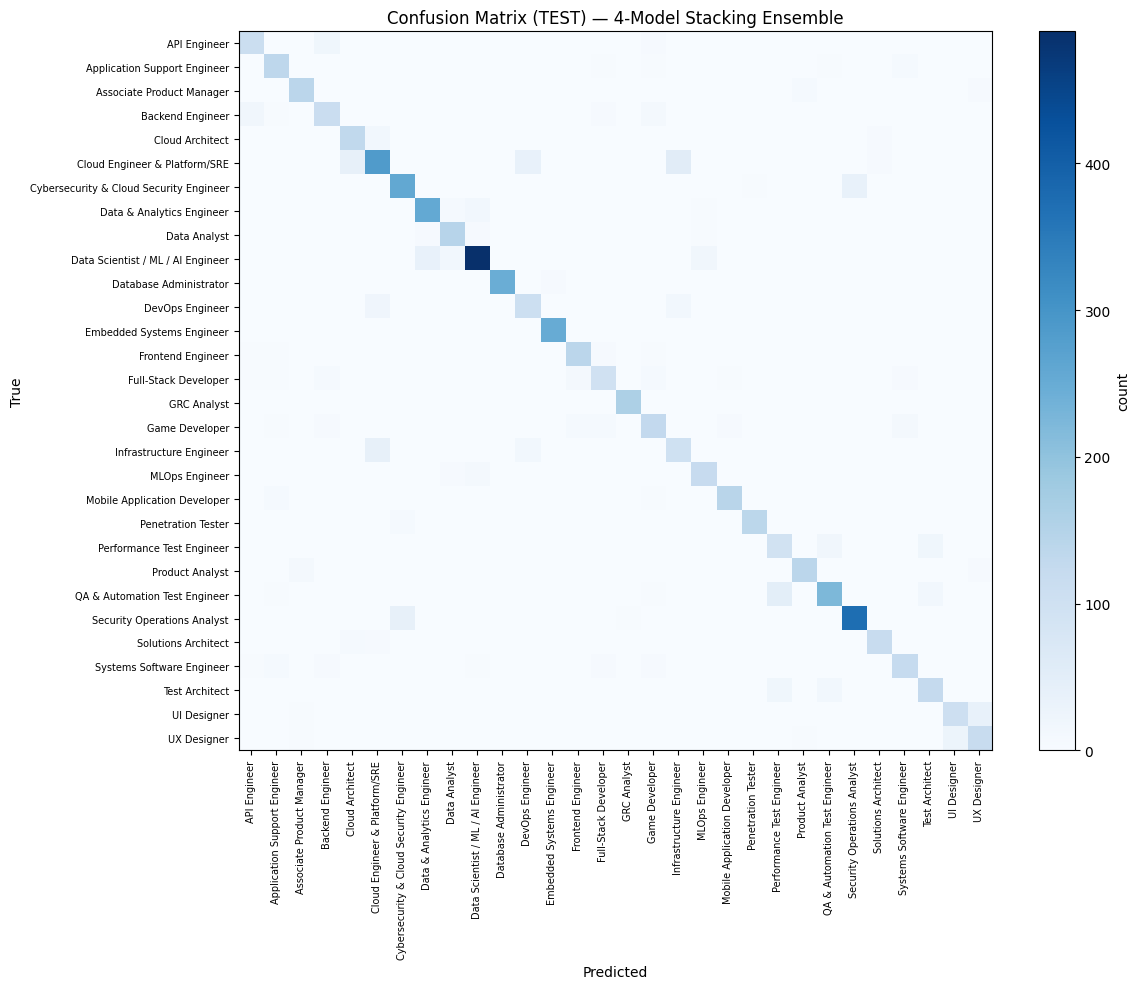

Saved ensemble_classification_report_test.txt / .csv
Saved ensemble_confusion_matrix_test.csv and .png


In [51]:
# Reports + Confusion matrices
# Classification report
report_txt = classification_report(
    y_test_enc, ens_pred_test,
    target_names=label_encoder.classes_,
    zero_division=0
)
print(report_txt)
(OUT_DIR / "ensemble_classification_report_test.txt").write_text(report_txt)

report_dict_test = classification_report(
    y_test_enc, ens_pred_test,
    target_names=label_encoder.classes_,
    output_dict=True, zero_division=0
)
pd.DataFrame(report_dict_test).T.to_csv(
    OUT_DIR / "ensemble_classification_report_test.csv", index=True
)

# Confusion matrix
cm    = confusion_matrix(y_test_enc, ens_pred_test)
cm_df = pd.DataFrame(cm,
                     index=label_encoder.classes_,
                     columns=label_encoder.classes_)
cm_df.to_csv(OUT_DIR / "ensemble_confusion_matrix_test.csv", index=True)

plt.figure(figsize=(12, 10))
plt.imshow(cm, aspect="auto", cmap="Blues")
plt.colorbar(label="count")
plt.xticks(range(len(label_encoder.classes_)),
           label_encoder.classes_, rotation=90, fontsize=7)
plt.yticks(range(len(label_encoder.classes_)),
           label_encoder.classes_, fontsize=7)
plt.title("Confusion Matrix (TEST) — 4-Model Stacking Ensemble",
          fontsize=12)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(OUT_DIR / "ensemble_confusion_matrix_test.png", dpi=150)
plt.show()

print("Saved ensemble_classification_report_test.txt / .csv")
print("Saved ensemble_confusion_matrix_test.csv and .png")

In [52]:
# LAYER 7: Output Layer

In [53]:
# Load role->domain mapping
role_to_domain_path = OUT_DIR / "role_to_domain.json"
role_to_domain = (
    json.loads(role_to_domain_path.read_text())
    if role_to_domain_path.exists() else {}
)
print("role_to_domain loaded:", len(role_to_domain))

role_to_domain loaded: 30


In [54]:
# Part B: Helper: proba -> Top-1/Top-3 recommendations
def topk_from_proba(proba_row, k=3):
    idx   = np.argsort(proba_row)[::-1][:k]
    roles = label_encoder.inverse_transform(idx)
    probs = proba_row[idx]
    return [(roles[i], float(probs[i])) for i in range(len(idx))]


def output_df_from_proba(proba, k=3):
    rows = []
    for i in range(proba.shape[0]):
        topk = topk_from_proba(proba[i], k=k)
        topk = [(role, round(prob, 6)) for role, prob in topk]
        top1_role, top1_prob = topk[0]
        rows.append({
            "top1_role":   top1_role,
            "top1_prob":   round(top1_prob, 6),
            "top1_domain": role_to_domain.get(top1_role, "Unknown"),
            "low_confidence": top1_prob < 0.40,
            "top3":        topk,
        })
    return pd.DataFrame(rows)

In [55]:
# Generate outputs (Top-1 + Top-3) on TEST
ens_out = output_df_from_proba(ens_proba_test, k=3)
pd.set_option("display.max_colwidth", None)
display(ens_out.head(5))

ens_out.to_csv(OUT_DIR / "topk_outputs_test_ensemble.csv", index=False)
ens_out.to_csv(OUT_DIR / "topk_outputs_test_FINAL.csv",    index=False)

print("Saved topk_outputs_test_ensemble.csv")
print("Saved topk_outputs_test_FINAL.csv (same as ensemble)")
print(f"\n  Low confidence predictions (<40%): "
      f"{ens_out['low_confidence'].sum()} / {len(ens_out)} "
      f"({ens_out['low_confidence'].mean()*100:.1f}%)")

,top1_role,top1_prob,top1_domain,low_confidence,top3
0,Data Scientist / ML / AI Engineer,0.9602,Data & Artificial Intelligence,False,"[(Data Scientist / ML / AI Engineer, 0.960197), (Data & Analytics Engineer, 0.019629), (MLOps Engineer, 0.01081)]"
1,Database Administrator,0.9973,Systems & Infrastructure,False,"[(Database Administrator, 0.997273), (Embedded Systems Engineer, 0.000946), (API Engineer, 0.000102)]"
2,GRC Analyst,0.9974,Cybersecurity,False,"[(GRC Analyst, 0.997439), (Security Operations Analyst, 0.000347), (Data Analyst, 0.000196)]"
3,Security Operations Analyst,0.8842,Cybersecurity,False,"[(Security Operations Analyst, 0.88424), (Cybersecurity & Cloud Security Engineer, 0.106036), (GRC Analyst, 0.003017)]"
4,Infrastructure Engineer,0.5629,"Cloud, DevOps & Platform Engineering",False,"[(Infrastructure Engineer, 0.562935), (Cloud Engineer & Platform/SRE, 0.332012), (DevOps Engineer, 0.083825)]"


Saved topk_outputs_test_ensemble.csv
Saved topk_outputs_test_FINAL.csv (same as ensemble)

  Low confidence predictions (<40%): 84 / 6000 (1.4%)
